In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
import pathlib


In [3]:
data_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/")
train_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/train")
test_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/test")
valid_path = pathlib.Path("./BIRDS 525 SPECIES-DataSet/valid")

In [4]:
training_image_count = len(list(data_path.glob('train/*/*.jpg')))
test_image_count = len(list(data_path.glob('test/*/*.jpg')))
validation_image_count = len(list(data_path.glob('valid/*/*.jpg')))
total_count = training_image_count + test_image_count + validation_image_count

print(f"training_image_count: {training_image_count}")
print(f"test_image_count: {test_image_count}")
print(f"validation_image_count: {validation_image_count}")
print(f"total_count: {total_count}")

training_image_count: 84632
test_image_count: 2625
validation_image_count: 2625
total_count: 89882


In [5]:
batch_size = 32
img_height = 224
img_width = 224

train_ds = image_dataset_from_directory(
    train_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    valid_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_path,
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 84632 files belonging to 525 classes.
Found 2625 files belonging to 525 classes.
Found 2625 files belonging to 525 classes.
['ABBOTTS BABBLER', 'ABBOTTS BOOBY', 'ABYSSINIAN GROUND HORNBILL', 'AFRICAN CROWNED CRANE', 'AFRICAN EMERALD CUCKOO', 'AFRICAN FIREFINCH', 'AFRICAN OYSTER CATCHER', 'AFRICAN PIED HORNBILL', 'AFRICAN PYGMY GOOSE', 'ALBATROSS', 'ALBERTS TOWHEE', 'ALEXANDRINE PARAKEET', 'ALPINE CHOUGH', 'ALTAMIRA YELLOWTHROAT', 'AMERICAN AVOCET', 'AMERICAN BITTERN', 'AMERICAN COOT', 'AMERICAN DIPPER', 'AMERICAN FLAMINGO', 'AMERICAN GOLDFINCH', 'AMERICAN KESTREL', 'AMERICAN PIPIT', 'AMERICAN REDSTART', 'AMERICAN ROBIN', 'AMERICAN WIGEON', 'AMETHYST WOODSTAR', 'ANDEAN GOOSE', 'ANDEAN LAPWING', 'ANDEAN SISKIN', 'ANHINGA', 'ANIANIAU', 'ANNAS HUMMINGBIRD', 'ANTBIRD', 'ANTILLEAN EUPHONIA', 'APAPANE', 'APOSTLEBIRD', 'ARARIPE MANAKIN', 'ASHY STORM PETREL', 'ASHY THRUSHBIRD', 'ASIAN CRESTED IBIS', 'ASIAN DOLLARD BIRD', 'ASIAN GREEN BEE EATER', 'ASIAN OPENBILL STORK', 'AUCKLAND SHAQ', 'A

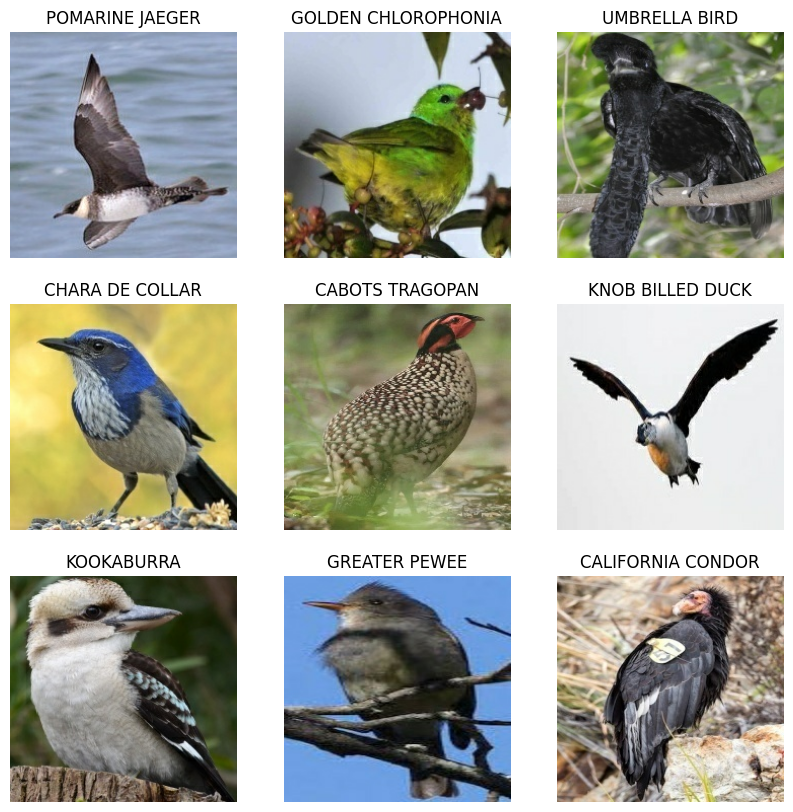

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [7]:
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [8]:
data_augmentation = tf.keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

c:\Users\armin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


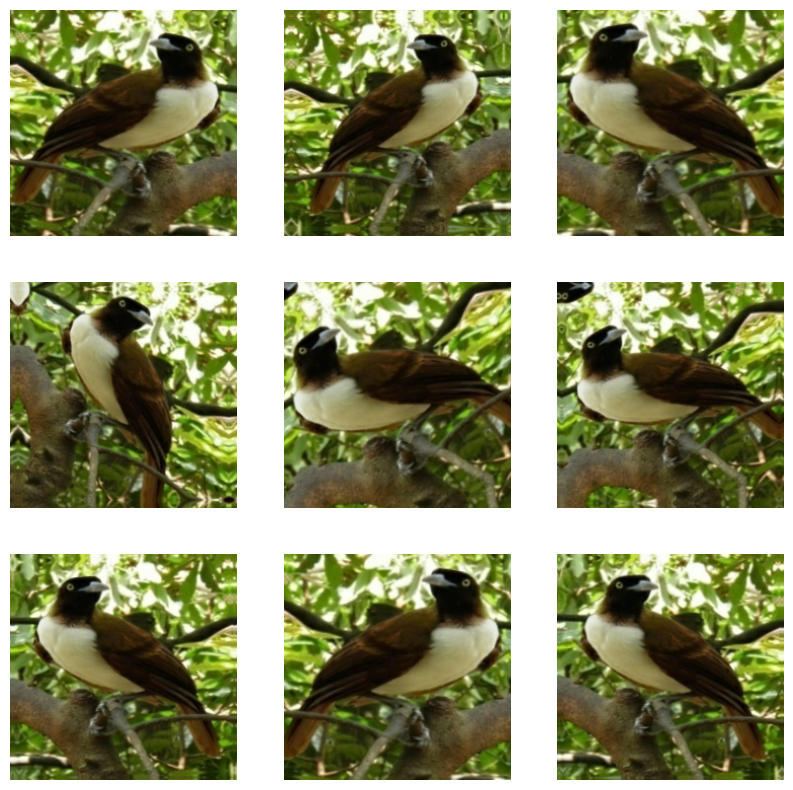

In [10]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [11]:
num_classes = len(class_names)

model = tf.keras.models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs", activation="softmax")
])

In [12]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 525)            │        67,725 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,513,965 (24.85 MB)

 Trainable params: 6,513,965 (24.85 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
epochs=20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20


2645/2645 ━━━━━━━━━━━━━━━━━━━━ 708s 267ms/step - accuracy: 0.0874 - loss: 4.9136 - val_accuracy: 0.2278 - val_loss: 3.7040
Epoch 2/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 731s 276ms/step - accuracy: 0.2488 - loss: 3.5784 - val_accuracy: 0.3451 - val_loss: 3.1233
Epoch 3/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 730s 276ms/step - accuracy: 0.3338 - loss: 3.0623 - val_accuracy: 0.4145 - val_loss: 2.7399
Epoch 4/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 726s 274ms/step - accuracy: 0.3849 - loss: 2.7830 - val_accuracy: 0.4617 - val_loss: 2.4402
Epoch 5/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 708s 268ms/step - accuracy: 0.4185 - loss: 2.5952 - val_accuracy: 0.4735 - val_loss: 2.3858
Epoch 6/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 706s 267ms/step - accuracy: 0.4450 - loss: 2.4596 - val_accuracy: 0.5257 - val_loss: 2.1800
Epoch 7/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 724s 274ms/step - accuracy: 0.4637 - loss: 2.3564 - val_accuracy: 0.4907 - val_loss: 2.3672
Epoch 8/20
2645/2645 ━━━━━━━━━━━━━━━━━━━━ 720s 272ms/step - accuracy: 0.4